In [2]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split


In [3]:
df = pd.read_csv('features.csv')
y = df['label']
X = df.drop(['label', 'filepath'], axis=1)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
train_data = lgb.Dataset(data=X_train, label=y_train)
test_data = lgb.Dataset(data=X_test, label=y_test, reference=train_data) 

In [6]:
params = {"objective": "binary", 
          "metric": "auc"}

In [ ]:
booster = lgb.train(
    params=params,
    train_set=train_data,
    num_boost_round=100,
    valid_sets=[train_data, test_data],
    callbacks=[lgb.log_evaluation(period=10)] 
)

[LightGBM] [Info] Number of positive: 614, number of negative: 1266
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003200 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2504
[LightGBM] [Info] Number of data points in the train set: 1880, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.326596 -> initscore=-0.723623
[LightGBM] [Info] Start training from score -0.723623
[10]	training's auc: 0.995478	valid_1's auc: 0.985838
[20]	training's auc: 0.998622	valid_1's auc: 0.990368
[30]	training's auc: 0.999711	valid_1's auc: 0.99088
[40]	training's auc: 0.999992	valid_1's auc: 0.993244
[50]	training's auc: 1	valid_1's auc: 0.993598
[60]	training's auc: 1	valid_1's auc: 0.993933
[70]	training's auc: 1	valid_1's auc: 0.993973
[80]	training's auc: 1	valid_1's auc: 0.994327
[90]	training's auc: 1	valid_1's auc: 0.994

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

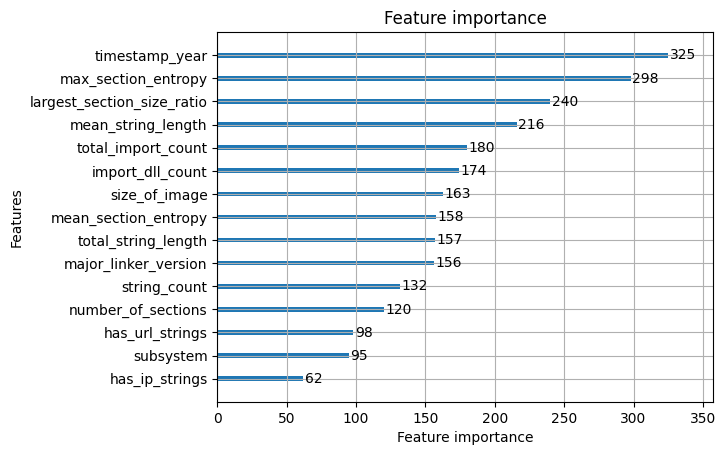

In [8]:
lgb.plot_importance(booster, importance_type='split', max_num_features=15)